# Model Parameters: Overview and Value Ranges

Overview of all input parameters used in the sensitivity analyses of both models  
(Schulz/Charbeneau: thermal breakthrough; Theis: injection pressure).  
For parameters appearing in both models, the wider value range is used.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------------------------------------------------
# Parameter data: (variable name, description, unit, category, min, max)
# For parameters appearing in both notebooks, the wider range is used.
# -----------------------------------------------------------------------
parameters = [
    # Technical parameters
    ('M',               'Aquifer Thickness',             'm',          'Technical',  25,      35      ),
    ('a',               'Half Well Spacing',              'm',          'Technical',  490,     510     ),
    ('Q',               'Flow Rate',                      'm³/s',       'Technical',  0.025,   0.035   ),
    ('rw',              'Well Radius',                    'm',          'Technical',  0.20,    0.25    ),
    ('skin',            'Skin Factor',                    '-',          'Technical',  0.0,     20.0    ),
    ('scale_loss_grad', 'Scaling Loss Gradient',          'Pa/(m³/s)', 'Technical',  0.0,     5e7     ),
    # Rock properties
    ('k',               'Intrinsic Permeability',         'm²',         'Rock',       1e-12,   3e-12   ),
    ('alpha',           'Matrix Compressibility',         '1/Pa',       'Rock',       1e-10,   1e-8    ),
    ('phi',             'Porosity',                       '-',          'Rock',       0.05,    0.30    ),
    ('rho_S',           'Rock Matrix Density',            'kg/m³',      'Rock',       2500,    2800    ),
    ('c_S',             'Rock Heat Capacity',             'J/(kg·K)',   'Rock',       500,     1000    ),
    ('lambda_S',        'Rock Thermal Conductivity',      'W/(m·K)',    'Rock',       2.5,     3.5     ),
    # Fluid properties
    ('rho_F',           'Fluid Density',                  'kg/m³',      'Fluid',      980,     1200    ),
    ('c_F',             'Fluid Heat Capacity',            'J/(kg·K)',   'Fluid',      4100,    4300    ),
    ('beta',            'Fluid Compressibility',          '1/Pa',       'Fluid',      4.0e-10, 5.0e-10 ),
    ('mu',              'Dynamic Viscosity',              'Pa·s',       'Fluid',      3e-4,    2e-3    ),
]

df = pd.DataFrame(
    parameters,
    columns=['Variable', 'Description', 'Unit', 'Category', 'Min', 'Max']
)

## Parameter Table

In [5]:
df_display = df[['Category', 'Variable', 'Description', 'Unit', 'Min', 'Max']].copy()
df_display = df_display.set_index(['Category', 'Variable'])
df_display.style.format({'Min': '{:.4g}', 'Max': '{:.4g}'})

## Tornado Plot: Parameter Uncertainty

Percentage deviation of the parameter range from the arithmetic mean (midpoint of Min and Max).  
Sorted by widest range at the top.

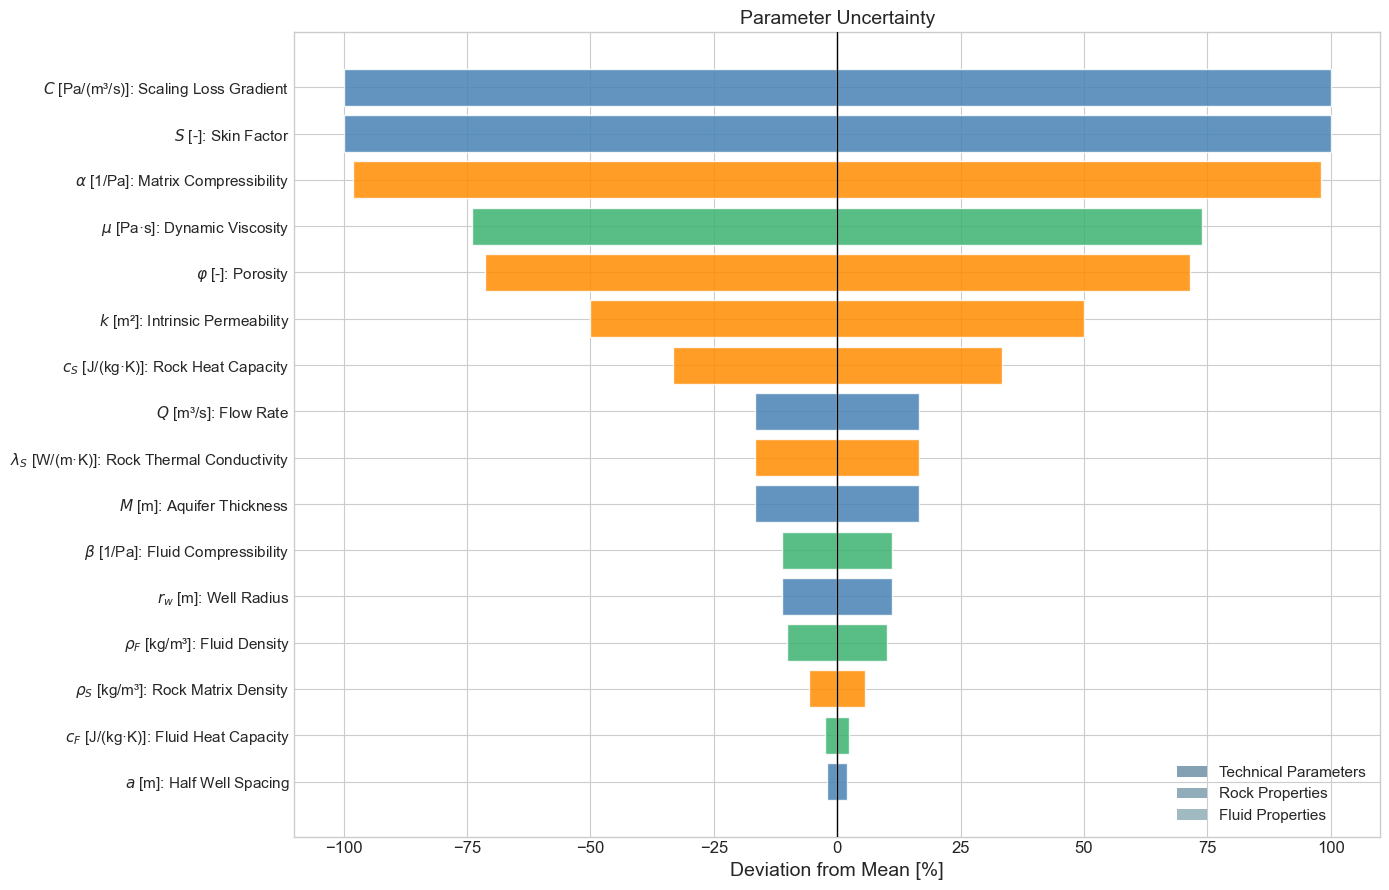

In [6]:
varnames  = df['Variable'].values
descs     = df['Description'].values
units     = df['Unit'].values
cats      = df['Category'].values
vmin      = df['Min'].values.astype(float)
vmax      = df['Max'].values.astype(float)

# Display names: Greek letters, subscripts, aliases
DISPLAY_NAMES = {
    'M':               r'$M$',
    'a':               r'$a$',
    'Q':               r'$Q$',
    'rw':              r'$r_w$',
    'skin':            r'$S$',
    'scale_loss_grad': r'$C$',
    'k':               r'$k$',
    'alpha':           r'$\alpha$',
    'phi':             r'$\varphi$',
    'rho_S':           r'$\rho_S$',
    'c_S':             r'$c_S$',
    'lambda_S':        r'$\lambda_S$',
    'rho_F':           r'$\rho_F$',
    'c_F':             r'$c_F$',
    'beta':            r'$\beta$',
    'mu':              r'$\mu$',
}

midpoint  = (vmin + vmax) / 2.0
lower_pct = (vmin - midpoint) / np.abs(midpoint) * 100.0
upper_pct = (vmax - midpoint) / np.abs(midpoint) * 100.0
total_pct = upper_pct - lower_pct

# Sort ascending: widest range at the top (highest y-index)
order = np.argsort(total_pct)

# Colors by category
CAT_COLOR = {
    'Technical': 'steelblue',
    'Rock':      'darkorange',
    'Fluid':     'mediumseagreen',
}

fig, ax = plt.subplots(figsize=(14, 9))
y = np.arange(len(parameters))

for j, i in enumerate(order):
    color = CAT_COLOR[cats[i]]
    ax.barh(j, lower_pct[i], color=color, alpha=0.85, edgecolor='white')
    ax.barh(j, upper_pct[i], color=color, alpha=0.85, edgecolor='white')
    #ax.text(lower_pct[i] - 0.5, j, f'{lower_pct[i]:.0f} %',
    #        ha='right', va='center', fontsize=9)
    #ax.text(upper_pct[i] + 0.5, j, f'+{upper_pct[i]:.0f} %',
    #        ha='left',  va='center', fontsize=9)

# Y-axis labels: display name – description [unit]
labels = [
    f'{DISPLAY_NAMES[varnames[i]]} [{units[i]}]: {descs[i]}'
    for i in order
]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.tick_params(axis='x', labelsize=12)

ax.axvline(0, color='black', linewidth=1.0, zorder=5)
ax.set_xlabel('Deviation from Mean [%]', fontsize=14)
ax.set_title('Parameter Uncertainty', fontsize=14)

legend_elements = [
    mpatches.Patch(facecolor='#6f8fa6',      alpha=0.85, label='Technical Parameters'),
    mpatches.Patch(facecolor='#7f9fae',     alpha=0.85, label='Rock Properties'),
    mpatches.Patch(facecolor='#8faeb6', alpha=0.85, label='Fluid Properties'),
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig('parameter_tornado.svg', bbox_inches='tight')
plt.show()